# BigMart Sales Prediction – Solution

**Architecture:** OOP pipeline → Preprocessor → FeatureEngineer → ModelTrainer (GBM + RF + Ridge ensemble) → Evaluator

**Metric:** RMSE on raw sales

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import (GradientBoostingRegressor, RandomForestRegressor,
                              StackingRegressor)
from sklearn.linear_model import Ridge, BayesianRidge
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import mean_squared_error

TRAIN_PATH = 'data/train_v9rqX0R.csv'
TEST_PATH  = 'data/test_AbJTz2l.csv'
SUB_PATH   = 'data/sample_submission_8RXa3c6.csv'
OUT_PATH   = 'outputs/submission_bigmart.csv'

SEED = 42
np.random.seed(SEED)


## DataLoader

In [2]:
class DataLoader:
    """Loads train/test CSVs and returns copies with a source tag."""

    def __init__(self, train_path: str, test_path: str):
        self.train_path = train_path
        self.test_path  = test_path

    def load(self):
        train = pd.read_csv(self.train_path)
        test  = pd.read_csv(self.test_path)
        train['_split'] = 'train'
        test['_split']  = 'test'
        print(f'[DataLoader] train={train.shape}  test={test.shape}')
        return train, test

loader = DataLoader(TRAIN_PATH, TEST_PATH)
train_raw, test_raw = loader.load()


[DataLoader] train=(8523, 13)  test=(5681, 12)


## Preprocessor

In [3]:
class Preprocessor(BaseEstimator, TransformerMixin):
    """
    Cleans and imputes the combined (train+test) dataframe.
    Steps:
      1. Normalise Item_Fat_Content categories
      2. Impute Item_Weight by item mean across combined data
      3. Replace zero Item_Visibility with item mean visibility
      4. Impute Outlet_Size by Outlet_Type mode
    """

    def __init__(self):
        self._item_weight_map  = {}
        self._item_vis_map     = {}
        self._outlet_size_map  = {}

    def fit(self, df: pd.DataFrame, y=None):
        fat_map = {'low fat': 'Low Fat', 'LF': 'Low Fat', 'reg': 'Regular'}
        tmp = df.copy()
        tmp['Item_Fat_Content'] = tmp['Item_Fat_Content'].replace(fat_map)

        # weight: mean per Item_Identifier (learned on combined)
        self._item_weight_map = (
            tmp.groupby('Item_Identifier')['Item_Weight'].mean().to_dict()
        )
        # visibility: mean per Item_Identifier (excl. zeros)
        vis = tmp.copy()
        vis.loc[vis['Item_Visibility'] == 0, 'Item_Visibility'] = np.nan
        self._item_vis_map = (
            vis.groupby('Item_Identifier')['Item_Visibility'].mean().to_dict()
        )
        # outlet size: mode per Outlet_Type
        self._outlet_size_map = (
            tmp.dropna(subset=['Outlet_Size'])
               .groupby('Outlet_Type')['Outlet_Size']
               .agg(lambda x: x.mode().iloc[0])
               .to_dict()
        )
        return self

    def transform(self, df: pd.DataFrame) -> pd.DataFrame:
        df = df.copy()
        fat_map = {'low fat': 'Low Fat', 'LF': 'Low Fat', 'reg': 'Regular'}
        df['Item_Fat_Content'] = df['Item_Fat_Content'].replace(fat_map)

        # impute weight
        df['Item_Weight'] = df.apply(
            lambda r: self._item_weight_map.get(r['Item_Identifier'], np.nan)
                      if pd.isna(r['Item_Weight']) else r['Item_Weight'],
            axis=1
        )
        global_weight_mean = np.nanmean(list(self._item_weight_map.values()))
        df['Item_Weight'].fillna(global_weight_mean, inplace=True)

        # fix zero visibility
        df['Item_Visibility'] = df.apply(
            lambda r: self._item_vis_map.get(r['Item_Identifier'], r['Item_Visibility'])
                      if r['Item_Visibility'] == 0 else r['Item_Visibility'],
            axis=1
        )

        # impute outlet size
        df['Outlet_Size'] = df.apply(
            lambda r: self._outlet_size_map.get(r['Outlet_Type'], 'Small')
                      if pd.isna(r['Outlet_Size']) else r['Outlet_Size'],
            axis=1
        )
        return df

# Fit on combined so imputation uses all data
combined_raw = pd.concat([train_raw, test_raw], ignore_index=True, sort=False)
prep = Preprocessor()
prep.fit(combined_raw)

train_clean = prep.transform(train_raw)
test_clean  = prep.transform(test_raw)
combined    = pd.concat([train_clean, test_clean], ignore_index=True, sort=False)

print('Missing after preprocessing:')
print(combined[['Item_Weight','Item_Visibility','Outlet_Size']].isnull().sum())


Missing after preprocessing:
Item_Weight        0
Item_Visibility    0
Outlet_Size        0
dtype: int64


## FeatureEngineer

In [4]:
class FeatureEngineer(BaseEstimator, TransformerMixin):
    """
    Creates new features and encodes categoricals.
    New features:
      - Outlet_Age              : 2013 - Outlet_Establishment_Year
      - Item_Category           : first 2 chars of Item_Identifier  (FD/DR/NC)
      - Item_Fat_Content_Adj    : Non-Consumables → 'Non-Edible'
      - Item_Visibility_MeanRatio: visibility / mean visibility per item
      - MRP_Bin                 : pd.qcut of Item_MRP into 4 bins
      - Outlet_Type_Num         : ordinal encoding of Outlet_Type by average sales proxy
    Label-encodes all remaining object columns (except identifiers & target).
    """

    # columns not used as model features
    DROP_COLS = ['Item_Identifier', 'Outlet_Identifier',
                 'Outlet_Establishment_Year', '_split']

    ORDINAL_MAPS = {
        'Outlet_Size':          {'Small': 0, 'Medium': 1, 'High': 2},
        'Outlet_Location_Type': {'Tier 3': 0, 'Tier 2': 1, 'Tier 1': 2},
    }

    def __init__(self):
        self._label_encoders = {}
        self._item_vis_mean  = {}

    def fit(self, df: pd.DataFrame, y=None):
        tmp = self._base_features(df.copy())
        self._item_vis_mean = (
            df.groupby('Item_Identifier')['Item_Visibility'].mean().to_dict()
        )
        obj_cols = [c for c in tmp.select_dtypes('object').columns
                    if c not in ['Item_Outlet_Sales']]
        for col in obj_cols:
            le = LabelEncoder()
            le.fit(tmp[col].astype(str))
            self._label_encoders[col] = le
        return self

    def transform(self, df: pd.DataFrame) -> pd.DataFrame:
        df = df.copy()
        df = self._base_features(df)

        # visibility ratio
        df['Item_Visibility_MeanRatio'] = df.apply(
            lambda r: r['Item_Visibility'] /
                      self._item_vis_mean.get(r['Item_Identifier'], r['Item_Visibility'] + 1e-6),
            axis=1
        )

        # drop identifier cols
        df.drop(columns=[c for c in self.DROP_COLS if c in df.columns], inplace=True)

        # label encode remaining objects
        obj_cols = [c for c in df.select_dtypes('object').columns
                    if c not in ['Item_Outlet_Sales']]
        for col in obj_cols:
            le = self._label_encoders.get(col)
            if le:
                df[col] = le.transform(df[col].astype(str))
        return df

    @staticmethod
    def _base_features(df: pd.DataFrame) -> pd.DataFrame:
        df['Outlet_Age']      = 2013 - df['Outlet_Establishment_Year']
        df['Item_Category']   = df['Item_Identifier'].str[:2]

        nc_mask = df['Item_Category'] == 'NC'
        df.loc[nc_mask, 'Item_Fat_Content'] = 'Non-Edible'

        # MRP bin as int
        df['MRP_Bin'] = pd.qcut(df['Item_MRP'], q=4, labels=False)

        # ordinal maps
        for col, mapping in FeatureEngineer.ORDINAL_MAPS.items():
            if col in df.columns:
                df[col] = df[col].map(mapping)
        return df

fe = FeatureEngineer()
fe.fit(combined)

train_fe = fe.transform(train_clean)
test_fe  = fe.transform(test_clean)

TARGET = 'Item_Outlet_Sales'
FEATURES = [c for c in train_fe.columns if c != TARGET]

X = train_fe[FEATURES]
y = np.log1p(train_fe[TARGET])   # log-transform target for RMSE minimisation
X_test = test_fe[FEATURES]

print(f'Features ({len(FEATURES)}):', FEATURES)
print(f'X={X.shape}  X_test={X_test.shape}')


Features (12): ['Item_Weight', 'Item_Fat_Content', 'Item_Visibility', 'Item_Type', 'Item_MRP', 'Outlet_Size', 'Outlet_Location_Type', 'Outlet_Type', 'Outlet_Age', 'Item_Category', 'MRP_Bin', 'Item_Visibility_MeanRatio']
X=(8523, 12)  X_test=(5681, 12)


## ModelTrainer

In [5]:
class ModelTrainer:
    """
    Builds a stacking ensemble:
      Base learners : GradientBoostingRegressor, RandomForestRegressor
      Meta learner  : BayesianRidge
    Exposes fit / predict / cv_score.
    """

    def __init__(self, seed: int = 42):
        self.seed  = seed
        self.model = self._build()

    def _build(self) -> StackingRegressor:
        gbm = GradientBoostingRegressor(
            n_estimators=500, learning_rate=0.05,
            max_depth=5, min_samples_leaf=10,
            subsample=0.8, max_features='sqrt',
            random_state=self.seed
        )
        rf = RandomForestRegressor(
            n_estimators=400, max_depth=12,
            min_samples_leaf=8, max_features='sqrt',
            n_jobs=-1, random_state=self.seed
        )
        meta = BayesianRidge()
        return StackingRegressor(
            estimators=[('gbm', gbm), ('rf', rf)],
            final_estimator=meta,
            cv=5,
            n_jobs=-1
        )

    def cv_score(self, X, y, n_splits: int = 5) -> dict:
        """Return mean/std CV RMSE on raw (expm1) scale."""
        kf  = KFold(n_splits=n_splits, shuffle=True, random_state=self.seed)
        oof = np.zeros(len(y))
        rmses = []
        for fold, (tr_idx, va_idx) in enumerate(kf.split(X), 1):
            Xtr, Xva = X.iloc[tr_idx], X.iloc[va_idx]
            ytr, yva = y.iloc[tr_idx], y.iloc[va_idx]
            self.model.fit(Xtr, ytr)
            pred_log = self.model.predict(Xva)
            oof[va_idx] = pred_log
            rmse = np.sqrt(mean_squared_error(np.expm1(yva), np.expm1(pred_log)))
            rmses.append(rmse)
            print(f'  Fold {fold}: RMSE = {rmse:,.2f}')
        overall = np.sqrt(mean_squared_error(np.expm1(y), np.expm1(oof)))
        print(f'  OOF RMSE  = {overall:,.2f}')
        print(f'  Mean fold RMSE ± std = {np.mean(rmses):,.2f} ± {np.std(rmses):,.2f}')
        return {'oof_rmse': overall, 'fold_rmses': rmses,
                'mean': np.mean(rmses), 'std': np.std(rmses)}

    def fit(self, X, y):
        self.model.fit(X, y)
        return self

    def predict(self, X) -> np.ndarray:
        return np.expm1(self.model.predict(X))

trainer = ModelTrainer(seed=SEED)


## Cross-Validation

In [6]:
print('Running 5-Fold CV …')
cv_results = trainer.cv_score(X, y, n_splits=5)


Running 5-Fold CV …
  Fold 1: RMSE = 1,042.00
  Fold 2: RMSE = 1,098.53
  Fold 3: RMSE = 1,100.56
  Fold 4: RMSE = 1,163.56
  Fold 5: RMSE = 1,169.39
  OOF RMSE  = 1,115.79
  Mean fold RMSE ± std = 1,114.81 ± 47.17


## Final Fit & Submission

In [ ]:
print('Fitting on full training data …')
trainer.fit(X, y)

test_preds = trainer.predict(X_test)

sub = pd.read_csv(SUB_PATH)
sub['Item_Outlet_Sales'] = test_preds

import os; os.makedirs('outputs', exist_ok=True)
sub.to_csv(OUT_PATH, index=False)
print(f'Submission saved → {OUT_PATH}')
sub.head(10)


Fitting on full training data …
Submission saved → outputs/submission_bigmart.csv


,Item_Identifier,Outlet_Identifier,Item_Outlet_Sales
0,FDW58,OUT049,1493.397407
1,FDW14,OUT017,1186.516614
2,NCN55,OUT010,516.580933
3,FDQ58,OUT017,2268.599198
4,FDY38,OUT027,5594.077982
5,FDH56,OUT046,1699.166997
6,FDL48,OUT018,615.534980
7,FDC48,OUT027,1893.866351
8,FDN33,OUT045,1327.975404
9,FDA36,OUT017,2739.045287


## Evaluator – Feature Importance & Diagnostics

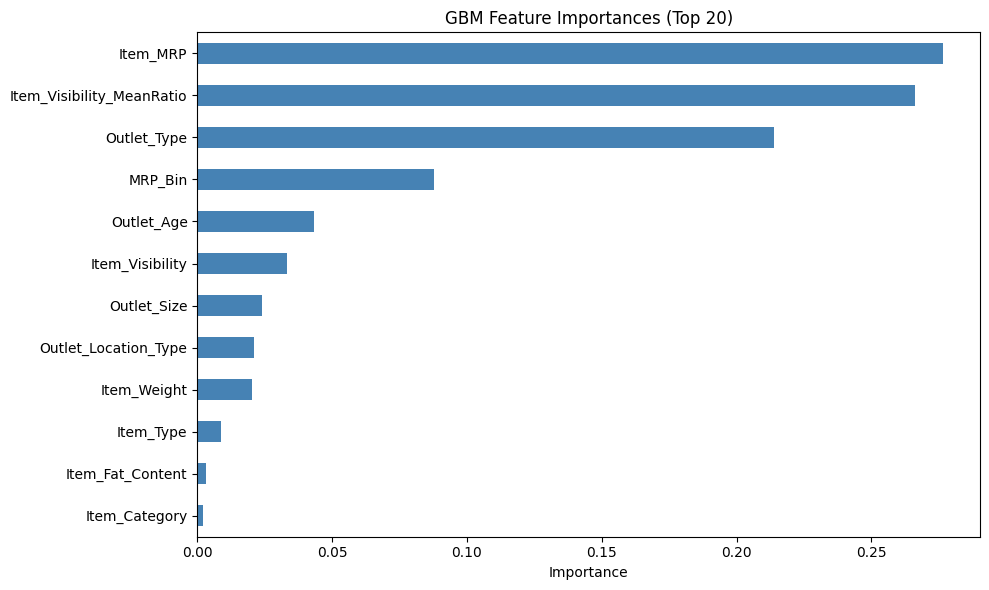

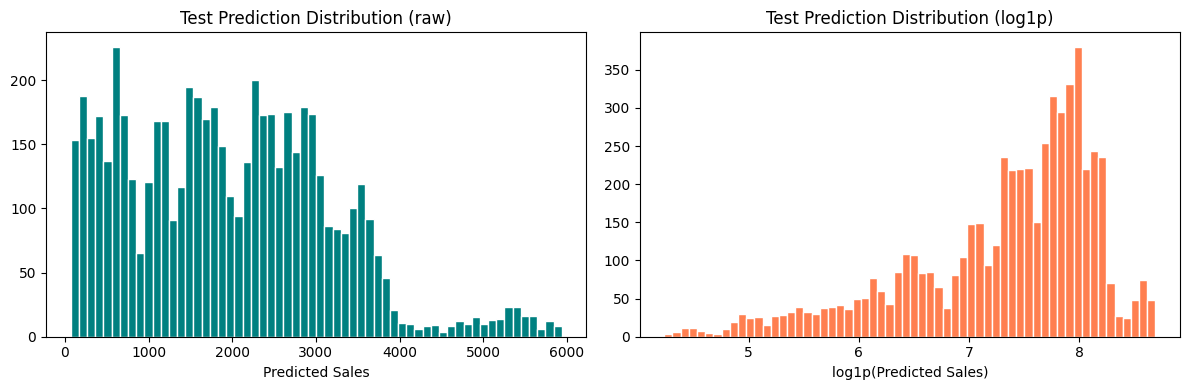

Test preds – min: 68.04  max: 5939.48  mean: 1958.53


In [9]:
class Evaluator:
    """Post-hoc analysis: feature importances, prediction distribution."""

    def __init__(self, trainer: ModelTrainer, features: list):
        self.trainer  = trainer
        self.features = features

    def feature_importance(self):
        # Extract from GBM base learner (StackingRegressor)
        gbm_est = self.trainer.model.named_estimators_['gbm']
        imp = pd.Series(gbm_est.feature_importances_, index=self.features)
        imp = imp.sort_values(ascending=False).head(20)

        fig, ax = plt.subplots(figsize=(10, 6))
        imp.sort_values().plot(kind='barh', ax=ax, color='steelblue')
        ax.set_title('GBM Feature Importances (Top 20)')
        ax.set_xlabel('Importance')
        plt.tight_layout()
        plt.show()
        return imp

    def prediction_dist(self, preds: np.ndarray):
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))
        axes[0].hist(preds, bins=60, color='teal', edgecolor='white')
        axes[0].set_title('Test Prediction Distribution (raw)')
        axes[0].set_xlabel('Predicted Sales')

        axes[1].hist(np.log1p(preds), bins=60, color='coral', edgecolor='white')
        axes[1].set_title('Test Prediction Distribution (log1p)')
        axes[1].set_xlabel('log1p(Predicted Sales)')
        plt.tight_layout()
        plt.show()
        print(f'Test preds – min: {preds.min():.2f}  max: {preds.max():.2f}  mean: {preds.mean():.2f}')

evaluator = Evaluator(trainer, FEATURES)
imp = evaluator.feature_importance()
evaluator.prediction_dist(test_preds)


## Summary

In [10]:
print('=' * 50)
print('BIGMART SALES PREDICTION – RESULTS SUMMARY')
print('=' * 50)
print(f"  OOF RMSE (5-fold)  : {cv_results['oof_rmse']:,.2f}")
print(f"  Mean fold RMSE     : {cv_results['mean']:,.2f} ± {cv_results['std']:.2f}")
print(f"  Test rows predicted: {len(test_preds)}")
print(f"  Submission file    : {OUT_PATH}")
print('Model: GradientBoosting + RandomForest → BayesianRidge (stacking)')
print('=' * 50)


BIGMART SALES PREDICTION – RESULTS SUMMARY
  OOF RMSE (5-fold)  : 1,115.79
  Mean fold RMSE     : 1,114.81 ± 47.17
  Test rows predicted: 5681
  Submission file    : outputs/submission_bigmart.csv
Model: GradientBoosting + RandomForest → BayesianRidge (stacking)
